In [ ]:
8. By using multinomial Naive Bayes, RandomForest, Logistic Regression classifiers, perform news
classification and analysis to categorize news articles into predefined categories and extract actionable
insights. Use AG_news dataset.

What you did:
Classified news into categories using ML models
🎯 Why we do it:

To automatically categorize text.

🌍 Use in NLP:
Google News
Email spam filtering
Content filtering

In [1]:
# Step 1: Import

# Data handling library
import pandas as pd

# Regular expressions and NLP tools
import re, nltk

# Stopwords for removing common words
from nltk.corpus import stopwords

# Tokenizer for splitting text into words
from nltk.tokenize import word_tokenize

# Lemmatizer for reducing words to base form
from nltk.stem import WordNetLemmatizer

# Machine learning utilities
from sklearn.model_selection import train_test_split

# Convert text into numerical features (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Download required NLTK datasets
nltk.download('punkt')      # tokenization
nltk.download('stopwords')  # stopword list
nltk.download('wordnet')    # lemmatization

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jaida\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jaida\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jaida\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# Step 2: Load Data (ONLY train.csv)
df = pd.read_csv("AG_news(train).csv")
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
# Step 3: Combine text (important)

# Merge Title and Description into a single text column
# This helps model learn from both fields together
df["text"] = df["Title"] + " " + df["Description"]

In [6]:
# Step 4: Preprocessing

# Load English stopwords into a set for faster lookup
stop_words = set(stopwords.words('english'))

# Initialize lemmatizer to convert words to base form
lemma = WordNetLemmatizer()

# Function to clean and preprocess text
def clean(text):
    
    # Convert text to lowercase and remove non-alphabet characters
    text = re.sub(r'[^a-z\s]', '', text.lower())
    
    # Tokenize text into words
    words = word_tokenize(text)
    
    # Remove stopwords and apply lemmatization
    return " ".join([lemma.lemmatize(w) for w in words if w not in stop_words])

# Apply preprocessing to entire dataset column
df["clean"] = df["text"].apply(clean)

In [7]:
# Step 5: Split data

# Split dataset into training and testing sets
# X = cleaned text, y = class labels
# test_size=0.2 → 20% data for testing, 80% for training
# random_state=42 → ensures same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    df["clean"], df["Class Index"], test_size=0.2, random_state=42
)

In [8]:
# Step 6: TF-IDF

# Initialize TF-IDF vectorizer (converts text into numerical features)
# max_features=5000 → keeps only top 5000 most important words
vec = TfidfVectorizer(max_features=5000)

# Fit on training data and transform it into TF-IDF features
X_train = vec.fit_transform(X_train)

# Transform test data using the same vectorizer (no re-fitting)
X_test = vec.transform(X_test)

In [9]:
#Step 8: Train Models

In [10]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [11]:
# Predict using Naive Bayes model on test data
nb_pred = nb.predict(X_test)

# Calculate accuracy by comparing predictions with actual labels
nb_acc = accuracy_score(y_test, nb_pred)

# Print model accuracy
print("Naive Bayes Accuracy:", nb_acc)

# Print detailed classification report (precision, recall, f1-score)
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8947083333333333
              precision    recall  f1-score   support

           1       0.90      0.88      0.89      5956
           2       0.94      0.97      0.96      6058
           3       0.86      0.86      0.86      5911
           4       0.88      0.86      0.87      6075

    accuracy                           0.89     24000
   macro avg       0.89      0.89      0.89     24000
weighted avg       0.89      0.89      0.89     24000



In [12]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [13]:
# Predict using Logistic Regression model on test data
lr_pred = lr.predict(X_test)

# Calculate accuracy by comparing predictions with actual labels
lr_acc = accuracy_score(y_test, lr_pred)

# Print model accuracy
print("Logistic Regression Accuracy:", lr_acc)

# Print detailed classification report (precision, recall, f1-score)
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.908
              precision    recall  f1-score   support

           1       0.92      0.90      0.91      5956
           2       0.95      0.98      0.96      6058
           3       0.87      0.88      0.87      5911
           4       0.89      0.88      0.88      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



In [14]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [15]:
# Predict using Random Forest model on test data
rf_pred = rf.predict(X_test)

# Calculate accuracy by comparing predictions with actual labels
rf_acc = accuracy_score(y_test, rf_pred)

# Print model accuracy
print("Random Forest Accuracy:", rf_acc)

# Print detailed classification report (precision, recall, f1-score)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.885125
              precision    recall  f1-score   support

           1       0.90      0.88      0.89      5956
           2       0.92      0.96      0.94      6058
           3       0.85      0.85      0.85      5911
           4       0.87      0.84      0.86      6075

    accuracy                           0.89     24000
   macro avg       0.88      0.88      0.88     24000
weighted avg       0.88      0.89      0.88     24000



<BarContainer object of 3 artists>

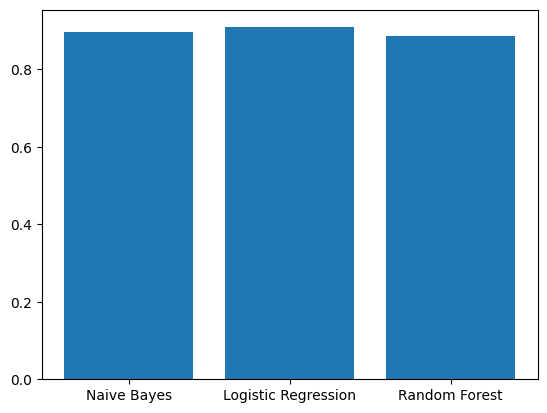

In [16]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# List of model names
models = ["Naive Bayes", "Logistic Regression", "Random Forest"]

# Corresponding accuracy values of each model
acc = [nb_acc, lr_acc, rf_acc]

# Create bar chart to compare model accuracies
plt.bar(models, acc)

In [17]:
# Step 11: Sample Prediction (Categorization)

# Mapping numerical labels to category names
labels = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

# Sample input text for prediction
sample = "Stock market rises due to tech growth"

# Clean the sample text using preprocessing function
sample_clean = clean(sample)

# Convert cleaned text into TF-IDF features and predict category using Logistic Regression
pred = lr.predict(vec.transform([sample_clean]))[0]

# Print the predicted category
print("Predicted Category:", labels[pred])

Predicted Category: Business


In [ ]:
1. What is news classification?

It is the process of categorizing news articles into predefined labels like sports, business, world, etc.

2. What dataset is used here?

AG News dataset, which contains labeled news articles across multiple categories.

3. What are the input and output of this system?

Input = news text
Output = category label (World, Sports, Business, Sci/Tech)

4. Why do we preprocess text?

To clean noise, remove stopwords, and improve model performance.

5. What is TF-IDF?

It is a method to convert text into numerical features based on word importance.

6. Why use TF-IDF instead of raw text?

Because ML models require numerical input, not raw text.

7. What is Multinomial Naive Bayes?

A probabilistic classifier commonly used for text classification.

8. Why is Naive Bayes good for text?

It works well with high-dimensional sparse data like text features.

9. What is Logistic Regression used for?

It is a linear classifier used for predicting categories.

10. What is Random Forest?

An ensemble model using multiple decision trees for better accuracy.

🔸 Deep / Conceptual QnA
11. Why compare multiple models?

To find the best-performing algorithm for the dataset.

12. Which model is generally best for text classification?

Logistic Regression or Naive Bayes (fast and effective for text).

13. Why is Naive Bayes called “naive”?

Because it assumes independence between features (words).

14. What is the limitation of Random Forest in text?

It is slower and less efficient for high-dimensional sparse text data.

15. Why does Logistic Regression perform well on TF-IDF?

Because it handles sparse, high-dimensional data efficiently.

16. What is classification report?

It shows precision, recall, F1-score, and accuracy.

17. What is precision and recall?

Precision = correctness of predictions
Recall = coverage of actual positives

18. What are actionable insights in news classification?

Insights like trend detection, market analysis, or category distribution.

19. How does TF-IDF help in feature selection?

It gives higher weight to important words and reduces common word impact.

20. What is overfitting in this context?

When model performs well on training data but poorly on test data.

🔥 High-Impact Viva Questions
21. Why is Naive Bayes strong despite simplicity?

Because it works well with probability-based text modeling.

22. Why is Logistic Regression widely used in NLP?

Because it is fast, interpretable, and works well with sparse data.

23. Why is Random Forest not always best for text?

Because text data is high-dimensional and sparse.

24. How would you improve accuracy?

Better preprocessing, n-grams, or deep learning models.

25. What is the real-world use of this system?

News apps, recommendation systems, and content filtering.